# 4 — Feedback loops and initial guesses

**The concept:** when two disciplines depend on each other, someone has to go first — and whoever
goes first reads a variable nobody has produced yet. That variable needs a **starting value**.

The hard part is not supplying it. The hard part is knowing *which* variable it is, because the
answer depends on the solver and on your **step names**.

In [1]:
from smartmdao import Pipeline, HybridSolver, analyze

sellar = Pipeline(solver=HybridSolver())

@sellar.step(outputs=["y1"])
def discipline_1(z: float, y2: float) -> float:
    return z**2 - 0.2 * y2

@sellar.step(outputs=["y2"])
def discipline_2(y1: float) -> float:
    return abs(y1) ** 0.5

report = analyze(sellar, inputs=["z"])
print("cycle:              ", report.cycles[0].steps)
print("coupling variables: ", report.cycles[0].feedback_variables)
print("needs a seed for:   ", [g.variable for g in report.initial_guesses_required])

cycle:               ('discipline_1', 'discipline_2')
coupling variables:  ('y1', 'y2')
needs a seed for:    ['y2']


The loop is visible before any of this is run — `y2` runs back up the
diagonal from `discipline_2` to `discipline_1`:

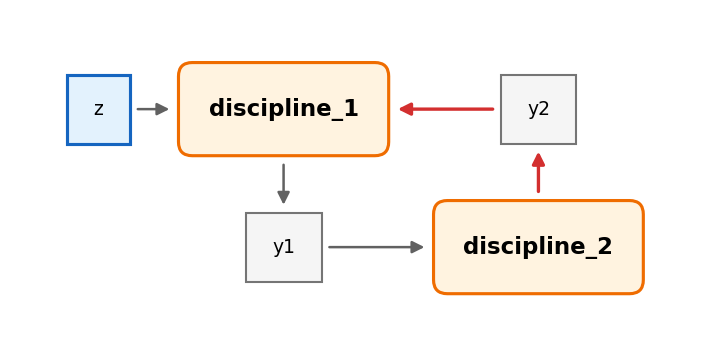

In [2]:
import matplotlib
matplotlib.use("Agg", force=True)

import pathlib, tempfile
from IPython.display import Image

_gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, inputs, name):
    """Render a pipeline to PNG and display it inline. See notebook 02."""
    path = _gallery / f"{name}.png"
    pipeline.visualize(inputs=inputs, output_path=str(path), view=False)
    return Image(filename=str(path))

show(sellar, ["z"], "sellar")

`analyze()` answered the question **without running anything**. Now supply what it asked for.

In [3]:
result = sellar.run(z=2.0, y2=1.0)
print(f"y1 = {result['y1']:.6f}")
print(f"y2 = {result['y2']:.6f}")

y1 = 3.619500
y2 = 1.902498


## Why it is `y2` and not `y1`

Inside a cyclic block `HybridSolver` runs the steps in **alphabetical order**, so the solve is
deterministic and repeatable. `discipline_1` sorts before `discipline_2`, so it runs first — and it
reads `y2`, which nothing has produced yet.

The uncomfortable consequence: **renaming a step can change which variable you must seed.** Here is
the same model with the two functions renamed, and nothing else changed.

In [4]:
renamed = Pipeline(solver=HybridSolver())

@renamed.step(outputs=["y2"])
def alpha_first(y1: float) -> float:          # was discipline_2
    return abs(y1) ** 0.5

@renamed.step(outputs=["y1"])
def zulu_second(z: float, y2: float) -> float:  # was discipline_1
    return z**2 - 0.2 * y2

renamed_report = analyze(renamed, inputs=["z"])
print("execution order:", renamed_report.execution_order)
print("needs a seed for:", [g.variable for g in renamed_report.initial_guesses_required])

execution order: ('alpha_first', 'zulu_second')
needs a seed for: ['y1']


The seed moved from `y2` to `y1`. Identical physics, identical graph, different requirement —
purely because of the letters the functions are named with.

**So do not reason it out. Ask.** Getting it wrong is not a helpful error either; it is a `KeyError`
from deep inside the solve.

In [5]:
try:
    sellar.run(z=2.0, y1=1.0)          # seeding the wrong one
except KeyError as error:
    print(f"KeyError: {error}")

Step 'discipline_1' cannot run. Missing inputs: ['y2']. Available in memory: ['z', 'y1']


Pipeline execution failed: "Step 'discipline_1' cannot run. Missing inputs: ['y2']. Available in memory: ['z', 'y1']"


KeyError: "Step 'discipline_1' cannot run. Missing inputs: ['y2']. Available in memory: ['z', 'y1']"


## `InitialGuess` tells you who is asking

Each entry names the variable *and* the step that reaches for it first, which is usually enough to
see why.

In [6]:
from smartmdao import InitialGuess

for guess in report.initial_guesses_required:
    print(f"{guess.variable!r} is read first by {guess.consumed_by!r}")

print()
print(isinstance(report.initial_guesses_required[0], InitialGuess))

'y2' is read first by 'discipline_1'

True


## Several loops at once

`HybridSolver` finds every strongly connected component independently and converges each one. Here
two separate loops share nothing, and both are solved.

In [7]:
two_loops = Pipeline(solver=HybridSolver())

@two_loops.step(outputs=["a"])
def loop1_a(b: float) -> float:
    return 0.5 * b + 1.0

@two_loops.step(outputs=["b"])
def loop1_b(a: float) -> float:
    return a * 0.8

@two_loops.step(outputs=["p"])
def loop2_p(q: float) -> float:
    return 0.25 * q + 2.0

@two_loops.step(outputs=["q"])
def loop2_q(p: float) -> float:
    return p * 0.9

analysis = analyze(two_loops, inputs=[])
for index, cycle in enumerate(analysis.cycles, 1):
    print(f"loop {index}: {' <-> '.join(cycle.steps)}  on {cycle.feedback_variables}")

out = two_loops.run(b=0.0, q=0.0)
print()
print({k: round(v, 6) for k, v in out.items() if k in "abpq"})

loop 1: loop1_a <-> loop1_b  on ('a', 'b')
loop 2: loop2_p <-> loop2_q  on ('p', 'q')

{'b': 1.333333, 'q': 2.32258, 'a': 1.666666, 'p': 2.580645}


## A cycle you did not intend

The most valuable use of `analyze()` is finding a loop you did not know you had wired. A single
misnamed parameter is enough to create one.

In [8]:
accidental = Pipeline(solver=HybridSolver())

@accidental.step(outputs=["mass"])
def structure(load: float, mass: float) -> float:   # reads its OWN output
    return 100.0 + 0.1 * load + 0.05 * mass

@accidental.step(outputs=["load"])
def loads(speed: float) -> float:
    return speed * 10.0

print("cycles found:", [c.steps for c in analyze(accidental, inputs=["speed"]).cycles])

cycles found: [('structure',)]


---

**Next:** [5 — Convergence](05-convergence.ipynb) — how the loop decides it has finished, and how to
find out what it actually did.